In [19]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import log_loss

In [2]:
feat = pd.read_csv("outputs/match_features.csv", parse_dates=["date"])

CUTOFF = "2015-01-01"                       # ~11 years of history
train = feat[feat.date >= CUTOFF].copy()
print(len(train), "matches since", CUTOFF)

10986 matches since 2015-01-01


In [7]:
home = pd.DataFrame({
    "goals": train.home_score,
    "attack": train.home_team,
    "defend": train.away_team,
    "is_home":(~train.neutral).astype(int),
    "date": train.date
})

away = pd.DataFrame({
    "goals": train.away_score,
    "attack": train.away_team,
    "defend": train.home_team,
    "is_home": 0,
    "date": train.date
})

long = pd.concat([home, away], ignore_index=True)
print(long.shape)
long.head(15)

(21972, 5)


,goals,attack,defend,is_home,date
0,1,Bahrain,Jordan,0,2015-01-04
1,1,Iran,Iraq,0,2015-01-04
2,2,South Korea,Saudi Arabia,0,2015-01-04
3,1,South Africa,Zambia,1,2015-01-04
4,4,China,Oman,0,2015-01-05
5,1,Cameroon,DR Congo,1,2015-01-07
6,4,Australia,Kuwait,1,2015-01-09
7,1,Senegal,Gabon,0,2015-01-09
8,5,Burkina Faso,Eswatini,0,2015-01-10
9,1,Cameroon,South Africa,0,2015-01-10


In [8]:
cnt = pd.concat([train.home_team, train.away_team]).value_counts()
keep = set(cnt[cnt >=15].index)
m = train[train.home_team.isin(keep) & train.away_team.isin(keep)]

home = pd.DataFrame({
    "goals": m.home_score,
    "attack": m.home_team,
    "defend": m.away_team,
    "is_home":(~m.neutral).astype(int),
    "date": m.date
})

away = pd.DataFrame({
    "goals": m.away_score,
    "attack": m.away_team,
    "defend": m.home_team,
    "is_home": 0,
    "date": m.date
})

long = pd.concat([home, away], ignore_index=True)
print(f"{len(keep)} teams kept; all 48 WC sides clear the bar (min ~76 matches)")


233 teams kept; all 48 WC sides clear the bar (min ~76 matches)


In [9]:
HALF_LIFE_YEARS = 2.0
age = (long.date.max() - long.date).dt.days / 365.25
long["w"] = 0.5 ** (age / HALF_LIFE_YEARS)
print("a match 2 yrs old counts", round(0.5**1, 2),
      "| 6 yrs old counts", round(0.5**3, 3))

a match 2 yrs old counts 0.5 | 6 yrs old counts 0.125


In [11]:
model = smf.glm("goals ~ C(attack) + C(defend) + is_home",
                data=long, family=sm.families.Poisson(),
                freq_weights=long["w"].values).fit()

print("baseline (intercept):", round(model.params["Intercept"], 3))
print("home-goal edge:", round(model.params["is_home"], 3),
      "→ home teams score", round(np.exp(model.params["is_home"]), 2), "× as many")

baseline (intercept): -0.534
home-goal edge: 0.23 → home teams score 1.26 × as many


In [14]:
att, dfn = {}, {}
for name, val in model.params.items():
    if name.startswith("C(attack)[T."):  att[name[12:-1]] = val
    elif name.startswith("C(defend)[T."): dfn[name[12:-1]] = val
for t in keep:                              # the reference team sits at 0
    att.setdefault(t, 0.0); dfn.setdefault(t, 0.0)
S = pd.DataFrame({"attack": att, "defend": dfn})

print("Top attacks:", list(S.attack.sort_values(ascending=False).head(5).index))
print("Best defenses:", list(S.defend.sort_values().head(5).index))

Top attacks: ['Spain', 'Brazil', 'Germany', 'Portugal', 'France']
Best defenses: ['Argentina', 'Morocco', 'England', 'Ecuador', 'Spain']


In [15]:
INT  = model.params["Intercept"]
HOME = model.params["is_home"]

def lambdas(home_team, away_team, neutral=True):
    ish = 0 if neutral else 1
    lh = np.exp(INT + att[home_team] + dfn[away_team] + HOME * ish)   # home exp. goals
    la = np.exp(INT + att[away_team] + dfn[home_team])               # away exp. goals
    return lh, la

print(lambdas("Argentina", "France", neutral=True))   # ~ (1.21, 0.75)

(1.2081677455973279, 0.7541598307516102)


In [16]:
from scipy.stats import poisson
from scipy.optimize import minimize_scalar

def tau(x, y, lh, la, rho):
    if x==0 and y==0: return 1 - lh*la*rho
    if x==0 and y==1: return 1 + lh*rho
    if x==1 and y==0: return 1 + la*rho
    if x==1 and y==1: return 1 - rho
    return 1.0

# fit rho by max-likelihood on recent matches
rec = feat[(feat.date>="2018-01-01") & feat.home_team.isin(att) & feat.away_team.isin(att)]
obs = [(int(r.home_score), int(r.away_score), *lambdas(r.home_team, r.away_team, bool(r.neutral)))
       for r in rec.itertuples()]
def neg_ll(rho):
    return -sum(np.log(max(poisson.pmf(x,lh)*poisson.pmf(y,la)*tau(x,y,lh,la,rho), 1e-12))
                for x,y,lh,la in obs)
RHO = minimize_scalar(neg_ll, bounds=(-0.2, 0.2), method="bounded").x
print("fitted rho:", round(RHO, 4))     # ~ -0.04

fitted rho: -0.0398


In [17]:
MAXG = 10
def predict(home_team, away_team, neutral=True):
    lh, la = lambdas(home_team, away_team, neutral)
    M = np.outer(poisson.pmf(range(MAXG+1), lh), poisson.pmf(range(MAXG+1), la))
    for i in range(2):                       # apply DC correction to low scores
        for j in range(2):
            M[i, j] *= tau(i, j, lh, la, RHO)
    M /= M.sum()
    return {"lambda": (round(lh,2), round(la,2)),
            "home_win": round(np.tril(M, -1).sum(), 3),   # i > j
            "draw":     round(np.trace(M), 3),            # i = j
            "away_win": round(np.triu(M, 1).sum(), 3),    # i < j
            "score":    "{}-{}".format(*np.unravel_index(M.argmax(), M.shape))}

for h, a in [("Argentina","France"), ("Spain","Cape Verde"), ("Brazil","Morocco")]:
    print(f"{h} v {a}:", predict(h, a))

Argentina v France: {'lambda': (1.21, 0.75), 'home_win': 0.463, 'draw': 0.311, 'away_win': 0.226, 'score': '1-0'}
Spain v Cape Verde: {'lambda': (2.97, 0.42), 'home_win': 0.877, 'draw': 0.094, 'away_win': 0.028, 'score': '2-0'}
Brazil v Morocco: {'lambda': (1.06, 0.81), 'home_win': 0.402, 'draw': 0.329, 'away_win': 0.269, 'score': '0-0'}


In [18]:
import os, json
os.makedirs("outputs", exist_ok=True)
S.to_csv("outputs/team_strengths.csv")
json.dump({"intercept": INT, "home": HOME, "rho": RHO},
          open("outputs/_glm_meta.json", "w"))
print("saved strengths + model constants.")

saved strengths + model constants.


In [20]:
def rps_each(P, y):
    """Per-match RPS for ordered outcomes [home, draw, away]. Lower = better."""
    P = np.asarray(P)
    a = np.zeros((len(y), 3)); a[np.arange(len(y)), y] = 1     # one-hot actual
    cp = np.cumsum(P, axis=1)[:, :2]                           # cumulative predicted
    ca = np.cumsum(a, axis=1)[:, :2]                           # cumulative actual
    return np.sum((cp - ca) ** 2, axis=1) / 2

def rps(P, y): return rps_each(P, y).mean()

# sanity: perfect=0, predict-away-when-home=worst(1), predict-draw-when-home=0.5
print(rps_each([[1,0,0]], [0]), rps_each([[0,0,1]], [0]), rps_each([[0,1,0]], [0]))

[0.] [1.] [0.5]


In [21]:
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
import warnings; warnings.filterwarnings("ignore")

feat = pd.read_csv("outputs/match_features.csv", parse_dates=["date"])
feat["y"] = [0 if h>a else (1 if h==a else 2) for h,a in zip(feat.home_score, feat.away_score)]

def fit_poisson(as_of):
    """Your entire Day-3 pipeline, but trained ONLY on matches before `as_of`."""
    tr = feat[(feat.date < as_of) & (feat.date >= as_of - pd.Timedelta(days=int(11*365.25)))]
    cnt = pd.concat([tr.home_team, tr.away_team]).value_counts(); keep = set(cnt[cnt>=15].index)
    m = tr[tr.home_team.isin(keep) & tr.away_team.isin(keep)]
    h = pd.DataFrame({"goals":m.home_score,"attack":m.home_team,"defense":m.away_team,"is_home":(~m.neutral).astype(int),"date":m.date})
    a = pd.DataFrame({"goals":m.away_score,"attack":m.away_team,"defense":m.home_team,"is_home":0,"date":m.date})
    lg = pd.concat([h,a]); lg["w"] = 0.5**(((lg.date.max()-lg.date).dt.days/365.25)/2.0)
    mod = smf.glm("goals ~ C(attack)+C(defense)+is_home", data=lg, family=sm.families.Poisson(),
                  freq_weights=lg["w"].values).fit()
    att, dfn = {}, {}
    for n,v in mod.params.items():
        if n.startswith("C(attack)[T."):  att[n.split("[T.")[1][:-1]] = v
        elif n.startswith("C(defense)[T."): dfn[n.split("[T.")[1][:-1]] = v
    for t in keep: att.setdefault(t,0.0); dfn.setdefault(t,0.0)
    INT, HOME = mod.params["Intercept"], mod.params["is_home"]
    # rho fit (vectorised) on the recent block
    rb = m[m.date >= as_of - pd.Timedelta(days=int(8*365.25))]
    lh = np.exp(INT+rb.home_team.map(att)+rb.away_team.map(dfn)+HOME*(~rb.neutral)).values
    la = np.exp(INT+rb.away_team.map(att)+rb.home_team.map(dfn)).values
    xs, ys = rb.home_score.values, rb.away_score.values; base = poisson.pmf(xs,lh)*poisson.pmf(ys,la)
    def nll(r):
        t = np.ones_like(base)
        t = np.where((xs==0)&(ys==0),1-lh*la*r,t); t = np.where((xs==0)&(ys==1),1+lh*r,t)
        t = np.where((xs==1)&(ys==0),1+la*r,t);   t = np.where((xs==1)&(ys==1),1-r,t)
        return -np.sum(np.log(np.clip(base*t,1e-12,None)))
    RHO = minimize_scalar(nll, bounds=(-0.2,0.2), method="bounded").x
    return att, dfn, INT, HOME, RHO, keep

def poisson_wdl(att,dfn,INT,HOME,RHO, h,a,neutral):
    ish = 0 if neutral else 1
    lh = np.exp(INT+att[h]+dfn[a]+HOME*ish); la = np.exp(INT+att[a]+dfn[h])
    M = np.outer(poisson.pmf(range(11),lh), poisson.pmf(range(11),la))
    M[0,0]*=1-lh*la*RHO; M[0,1]*=1+lh*RHO; M[1,0]*=1+la*RHO; M[1,1]*=1-RHO; M/=M.sum()
    return [np.tril(M,-1).sum(), np.trace(M), np.triu(M,1).sum()]

In [22]:
from sklearn.linear_model import LogisticRegression
ELO_HA = 100.0

def fit_elo(as_of):
    tr = feat[(feat.date < as_of) & (feat.date >= as_of - pd.Timedelta(days=int(11*365.25)))].copy()
    tr["eff"] = tr.elo_home_pre - tr.elo_away_pre + ELO_HA*(~tr.neutral)   # one feature
    return LogisticRegression().fit(tr[["eff"]], tr.y)

def elo_wdl(lr, r):
    eff = r.elo_home_pre - r.elo_away_pre + ELO_HA*(not r.neutral)
    p = lr.predict_proba([[eff]])[0]; o = np.zeros(3)
    for c, pr in zip(lr.classes_, p): o[c] = pr
    return o

In [23]:
TEST_START = pd.Timestamp("2023-01-01")          # ~3.5 yrs incl. Euro 2024, Copa 2024
test = feat[feat.date >= TEST_START].sort_values("date")
quarters = pd.date_range(TEST_START, test.date.max(), freq="QS")

rows = []
for qi, q in enumerate(quarters):
    qend = quarters[qi+1] if qi+1 < len(quarters) else pd.Timestamp("2100-01-01")
    block = test[(test.date >= q) & (test.date < qend)]
    if not len(block): continue
    att,dfn,INT,HOME,RHO,keep = fit_poisson(q)    # REFIT on past-only, each quarter
    lr = fit_elo(q)
    for r in block.itertuples():
        if r.home_team in keep and r.away_team in keep:        # only teams the model knows
            rows.append((r.date, r.y,
                         *poisson_wdl(att,dfn,INT,HOME,RHO, r.home_team, r.away_team, bool(r.neutral)),
                         *elo_wdl(lr, r)))
R = pd.DataFrame(rows, columns=["date","y","pH","pD","pA","eH","eD","eA"])
print(f"Scored {len(R)} matches across {len(quarters)} quarterly refits")

Scored 3498 matches across 14 quarterly refits


In [25]:
base = np.tile([R.y.eq(0).mean(), R.y.eq(1).mean(), R.y.eq(2).mean()], (len(R),1))
for name, P in [("Base rates", base),
                ("Elo baseline", R[["eH","eD","eA"]].values),
                ("Poisson model", R[["pH","pD","pA"]].values)]:
    print(f"{name:<14} RPS {rps(P, R.y.values):.4f}   log-loss {log_loss(R.y, P, labels=[0,1,2]):.4f}")

Base rates     RPS 0.2288   log-loss 1.0551
Elo baseline   RPS 0.1680   log-loss 0.8652
Poisson model  RPS 0.1638   log-loss 0.8483


mean RPS gain +0.0042 | 95% CI [+0.0022, +0.0063] | Wilcoxon p=6.0e-05 | Poisson wins 54.5%


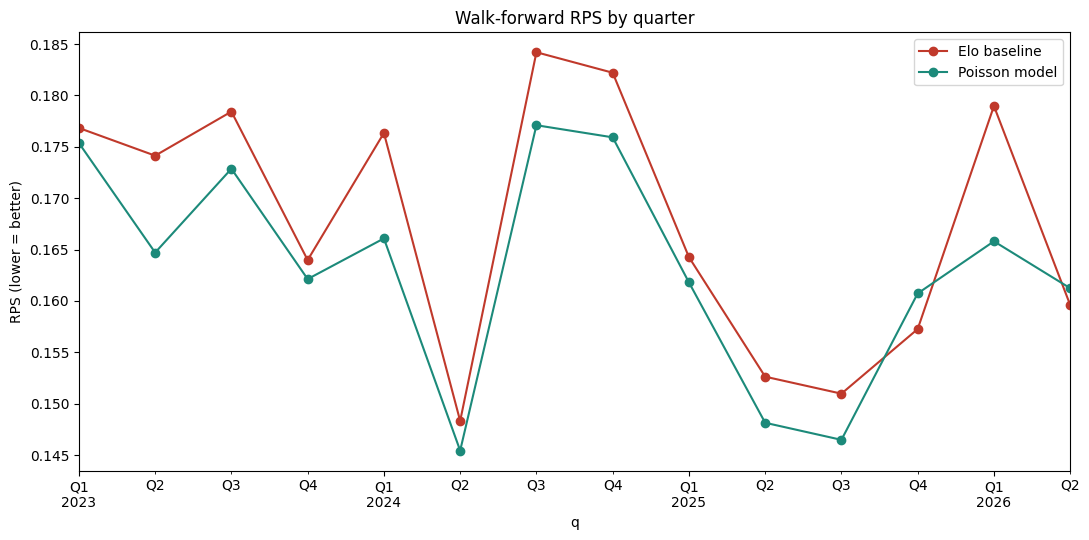

In [24]:
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

R["rps_p"] = rps_each(R[["pH","pD","pA"]].values, R.y.values)
R["rps_e"] = rps_each(R[["eH","eD","eA"]].values, R.y.values)
diff = R.rps_e - R.rps_p                                  # +ve => Poisson better

rng = np.random.default_rng(0)
boot = [rng.choice(diff.values, len(diff), replace=True).mean() for _ in range(2000)]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"mean RPS gain {diff.mean():+.4f} | 95% CI [{lo:+.4f}, {hi:+.4f}] "
      f"| Wilcoxon p={wilcoxon(diff).pvalue:.1e} | Poisson wins {(diff>0).mean()*100:.1f}%")

R["q"] = R.date.dt.to_period("Q")
pq = R.groupby("q")[["rps_e","rps_p"]].mean()
ax = pq.plot(marker="o", figsize=(11,5.5), color=["#c0392b","#1c8a7a"])
ax.set_ylabel("RPS (lower = better)"); ax.set_title("Walk-forward RPS by quarter")
ax.legend(["Elo baseline","Poisson model"]); plt.tight_layout(); plt.show()